# Task 3 — Random Forest + Optuna

**Name:** Abdlrhman Hisham Ismail · **ID:** AI2617

Use **Optuna** to search for the best **combination** of Random Forest hyperparameters on Red Wine Quality (binary), then evaluate the best trial on the held-out test set.


In [1]:
import sys
from pathlib import Path
ROOT = Path.cwd().parent if "Task" in Path.cwd().name else Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import accuracy_score, f1_score, classification_report, ConfusionMatrixDisplay

import optuna
from optuna.samplers import TPESampler

optuna.logging.set_verbosity(optuna.logging.WARNING)

from data_utils import load_wine_binary, dataset_info

print(dataset_info())
X_train, X_test, y_train, y_test = load_wine_binary()
print(f"Train: {X_train.shape} | Test: {X_test.shape}")
print("optuna", optuna.__version__)


Red Wine Quality (UCI / Kaggle) — binary label: good wine if quality >= 6. Features: fixed acidity, volatile acidity, citric acid, residual sugar, chlorides, free/total sulfur dioxide, density, pH, sulphates, alcohol.
Train: (1199, 11) | Test: (400, 11)
optuna 4.9.0


## Optuna search space

| Parameter | Range |
|-----------|--------|
| `n_estimators` | 50 … 400 |
| `max_depth` | 3 … 30 (or None via sentinel) |
| `min_samples_split` | 2 … 20 |
| `min_samples_leaf` | 1 … 10 |
| `max_features` | `{sqrt, log2, None}` |
| `criterion` | `{gini, entropy}` |

Objective: maximize **5-fold CV F1** on the training split.


In [2]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

def objective(trial: optuna.Trial) -> float:
    max_depth = trial.suggest_int("max_depth", 3, 30)
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 50, 400),
        "max_depth": max_depth,
        "min_samples_split": trial.suggest_int("min_samples_split", 2, 20),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 10),
        "max_features": trial.suggest_categorical("max_features", ["sqrt", "log2", None]),
        "criterion": trial.suggest_categorical("criterion", ["gini", "entropy"]),
        "random_state": 42,
        "n_jobs": -1,
    }
    model = RandomForestClassifier(**params)
    scores = cross_val_score(model, X_train, y_train, cv=cv, scoring="f1", n_jobs=-1)
    return float(scores.mean())


study = optuna.create_study(
    direction="maximize",
    sampler=TPESampler(seed=42),
    study_name="rf_wine_optuna",
)
study.optimize(objective, n_trials=50, show_progress_bar=False)

print("Best CV F1:", round(study.best_value, 4))
print("Best params:")
for k, v in study.best_params.items():
    print(f"  {k}: {v}")

trials_df = study.trials_dataframe()
trials_df.to_csv("results/optuna_trials.csv", index=False)


Best CV F1: 0.8215
Best params:
  max_depth: 30
  n_estimators: 324
  min_samples_split: 8
  min_samples_leaf: 1
  max_features: None
  criterion: entropy


In [3]:
best_params = dict(study.best_params)
best_params.update({"random_state": 42, "n_jobs": -1})
best_rf = RandomForestClassifier(**best_params)
best_rf.fit(X_train, y_train)

y_tr = best_rf.predict(X_train)
y_te = best_rf.predict(X_test)

print("=== Best Random Forest (Optuna) ===")
print(f"Train Acc={accuracy_score(y_train, y_tr):.4f}  F1={f1_score(y_train, y_tr):.4f}")
print(f"Test  Acc={accuracy_score(y_test, y_te):.4f}  F1={f1_score(y_test, y_te):.4f}")
print(classification_report(y_test, y_te, target_names=["bad", "good"]))

pd.DataFrame([{
    **study.best_params,
    "cv_f1": study.best_value,
    "train_f1": f1_score(y_train, y_tr),
    "test_f1": f1_score(y_test, y_te),
    "test_acc": accuracy_score(y_test, y_te),
}]).to_csv("results/best_rf_params.csv", index=False)


=== Best Random Forest (Optuna) ===
Train Acc=0.9842  F1=0.9852
Test  Acc=0.8050  F1=0.8186
              precision    recall  f1-score   support

         bad       0.79      0.78      0.79       186
        good       0.81      0.82      0.82       214

    accuracy                           0.81       400
   macro avg       0.80      0.80      0.80       400
weighted avg       0.80      0.81      0.80       400



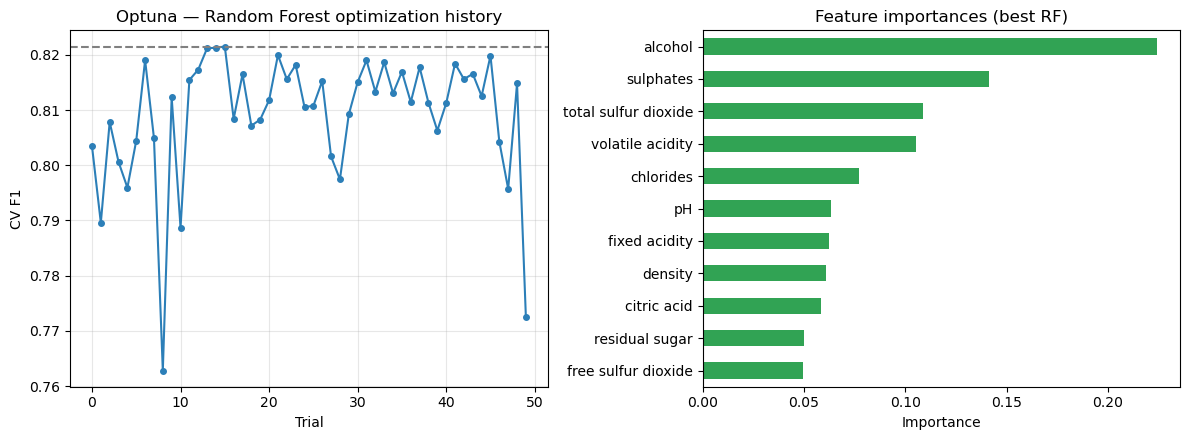

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].plot(trials_df["number"], trials_df["value"], "o-", color="#2c7fb8", ms=4)
axes[0].axhline(study.best_value, color="gray", ls="--")
axes[0].set_xlabel("Trial")
axes[0].set_ylabel("CV F1")
axes[0].set_title("Optuna — Random Forest optimization history")
axes[0].grid(True, alpha=0.3)

# Feature importances
imp = pd.Series(best_rf.feature_importances_, index=X_train.columns).sort_values()
imp.plot(kind="barh", ax=axes[1], color="#31a354")
axes[1].set_title("Feature importances (best RF)")
axes[1].set_xlabel("Importance")

fig.tight_layout()
fig.savefig("plots/optuna_rf_history_importance.png", dpi=150)
plt.show()


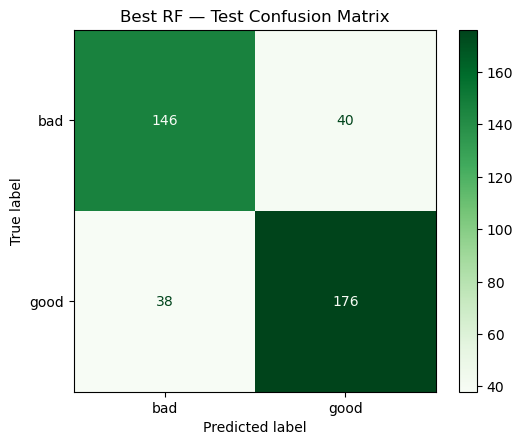

In [5]:
fig, ax = plt.subplots(figsize=(5.5, 4.5))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_te, display_labels=["bad", "good"], ax=ax, cmap="Greens"
)
ax.set_title("Best RF — Test Confusion Matrix")
fig.tight_layout()
fig.savefig("plots/rf_confusion.png", dpi=150)
plt.show()


## Observation

Optuna’s TPE sampler explores combinations of tree-count, depth, split/leaf constraints, and feature subsampling to maximize CV F1.  
The final model is refit on the full training set with the best parameter combination and scored once on the untouched test set.
